In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from pathlib import Path

DB_PATH = Path("../data/raw/ventas.db")
conn = sqlite3.connect(DB_PATH)
def sql(query, params=None):
    return pd.read_sql_query(query, conn, params=params)

# Construccion de Dataset de Clientes

In [2]:
df_clientes = sql("""
SELECT
    COUNT(*) AS total_compras,
    SUM(v.cantidad * p.precio_unitario * (1 - v.descuento_pct / 100.0)) AS ingreso_total,
    AVG(v.descuento_pct) AS descuento_promedio,
    AVG(v.cantidad) AS cantidad_promedio,
    COUNT(DISTINCT p.categoria) AS num_categorias
FROM ventas v
JOIN productos p
    on v.producto_id = p.producto_id
GROUP BY cliente_id
""")
df_clientes.head()

,total_compras,ingreso_total,descuento_promedio,cantidad_promedio,num_categorias
0,10,11539995.0,6.000000,4.700000,3
1,5,5689770.0,7.000000,5.000000,3
2,9,7765680.0,1.111111,3.777778,3
3,7,5055480.0,5.714286,4.714286,4
4,7,3966560.0,8.571429,3.000000,4


In [3]:
df_clientes["cliente_recurrente"] = (df_clientes["total_compras"] >= 6).astype(int)

In [4]:
df_clientes.head()

,total_compras,ingreso_total,descuento_promedio,cantidad_promedio,num_categorias,cliente_recurrente
0,10,11539995.0,6.000000,4.700000,3,1
1,5,5689770.0,7.000000,5.000000,3,0
2,9,7765680.0,1.111111,3.777778,3,1
3,7,5055480.0,5.714286,4.714286,4,1
4,7,3966560.0,8.571429,3.000000,4,1


In [5]:
df_clientes["cliente_recurrente"].value_counts()

cliente_recurrente
1    39
0    21
Name: count, dtype: int64

In [6]:
df_clientes.shape

(60, 6)

# EDA

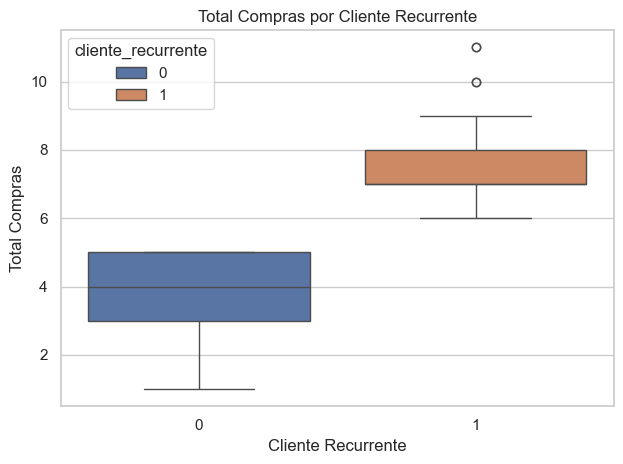

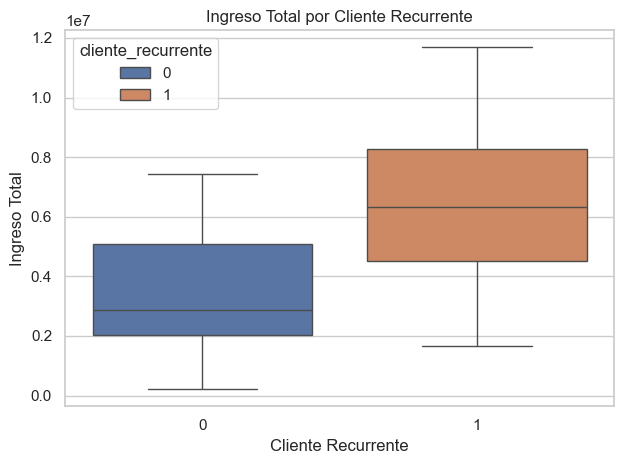

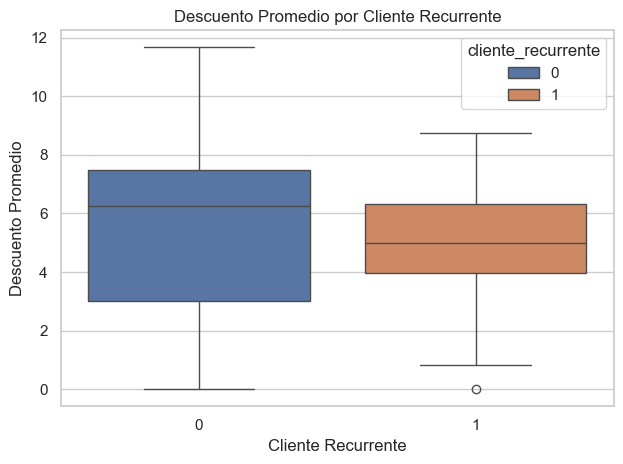

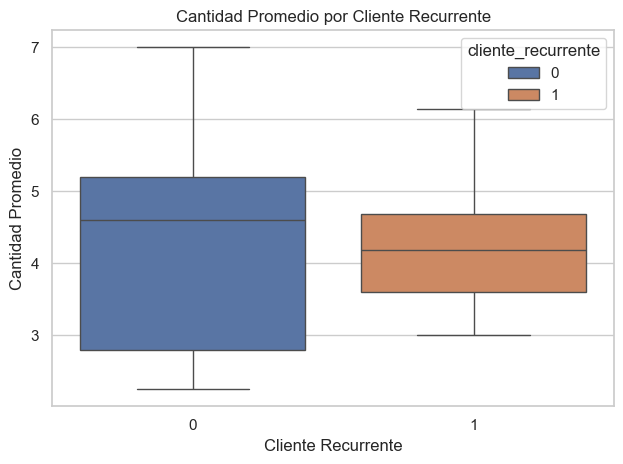

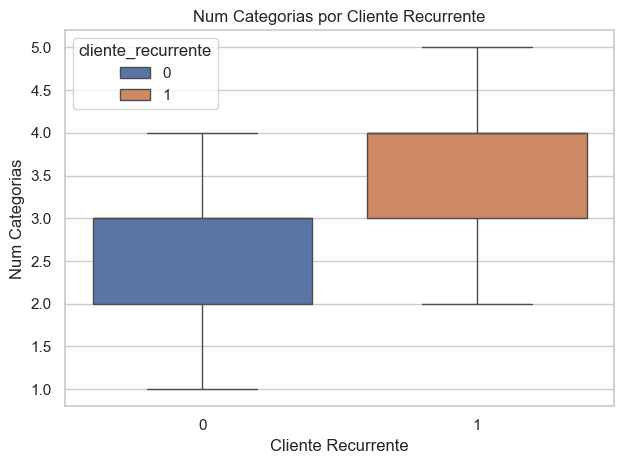

In [7]:
predecir = [
    "total_compras",
    "ingreso_total",
    "descuento_promedio",
    "cantidad_promedio",
    "num_categorias"
]
sns.set_theme(style="whitegrid", palette="deep")
for variable in predecir:
    plt.figure()
    sns.boxplot(
        data=df_clientes,
        x = "cliente_recurrente",
        y = variable,
        hue="cliente_recurrente"
    )
    plt.xlabel("Cliente Recurrente")
    plt.ylabel(variable.title().replace("_", " "))
    plt.title(f"{variable.title().replace("_", " ")} por Cliente Recurrente")
    plt.tight_layout()
    plt.show()

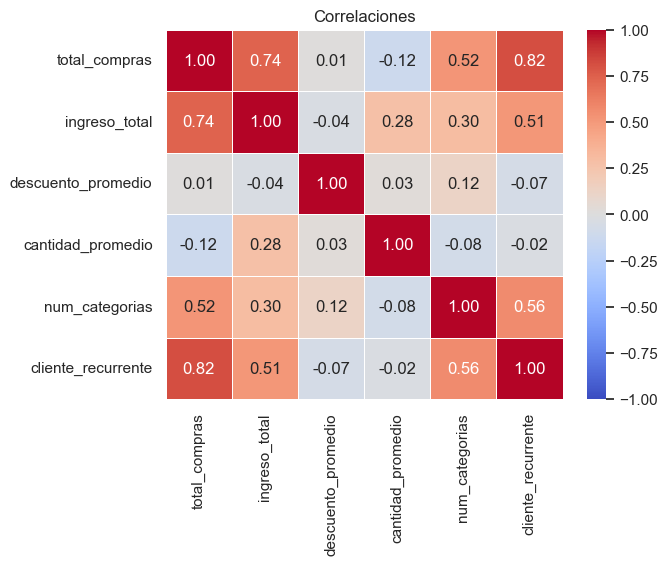

In [8]:
# Correlacion con cliente recurrente
corr = df_clientes.corr(numeric_only=True)
sns.set_theme(style="white")
sns.heatmap(
    data = corr,
    annot = True,
    cmap = "coolwarm",
    vmax = 1,
    vmin = -1,
    center = 0,
    fmt = ".2f",
    linecolor = "white",
    linewidths = .5
)
plt.title("Correlaciones")
plt.show()

# Preparacion de features y Train Test

In [9]:
X = df_clientes[['total_compras', 'ingreso_total', 'descuento_promedio',
       'cantidad_promedio', 'num_categorias']]
y = df_clientes['cliente_recurrente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [10]:
print(f"Filas en X test: {X_test.shape[0]}")
print(f"Filas en y test: {y_test.shape[0]}")

Filas en X test: 12
Filas en y test: 12


# Entrenamiento de modelos

## Logistic Regression

In [11]:
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_sc, y_train)
y_pred_lr = modelo_lr.predict(X_test_sc)

## KNN

In [12]:
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_sc, y_train)
y_pred_knn = modelo_knn.predict(X_test_sc)

## Decision Tree

In [13]:
modelo_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)

# Evaluacion y comparacion de Modelos

### Se espera que el modelo con mejor desempeño sea Logistic Regression ya que los features usados en ese modelo se trabajaron con standardscaler para poder estandarizar los valores y que ningun valor sea mas grande que otro, contando tambien con un bueno manejo de aleatoriedad para controlar los procesos aleatorios dentro del modelo

In [14]:
print(f"Metricas de Logistic Regression:\n{classification_report(y_test, y_pred_lr)}")
print("-" * 40)
print(f"Metricas de KNN:\n{classification_report(y_test, y_pred_knn)}")
print("-" * 40)
print(f"Metricas de Decision Tree:\n{classification_report(y_test, y_pred_dt)}")

Metricas de Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.89      1.00      0.94         8

    accuracy                           0.92        12
   macro avg       0.94      0.88      0.90        12
weighted avg       0.93      0.92      0.91        12

----------------------------------------
Metricas de KNN:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.89      1.00      0.94         8

    accuracy                           0.92        12
   macro avg       0.94      0.88      0.90        12
weighted avg       0.93      0.92      0.91        12

----------------------------------------
Metricas de Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         8

    accuracy           

In [16]:
resultados = pd.DataFrame({
    "Modelo": ["Decision Tree", "KNN", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_lr)
    ]
})
resultados

,Modelo,Accuracy
0,Decision Tree,1.000000
1,KNN,0.916667
2,Logistic Regression,0.916667


# Visualizacion

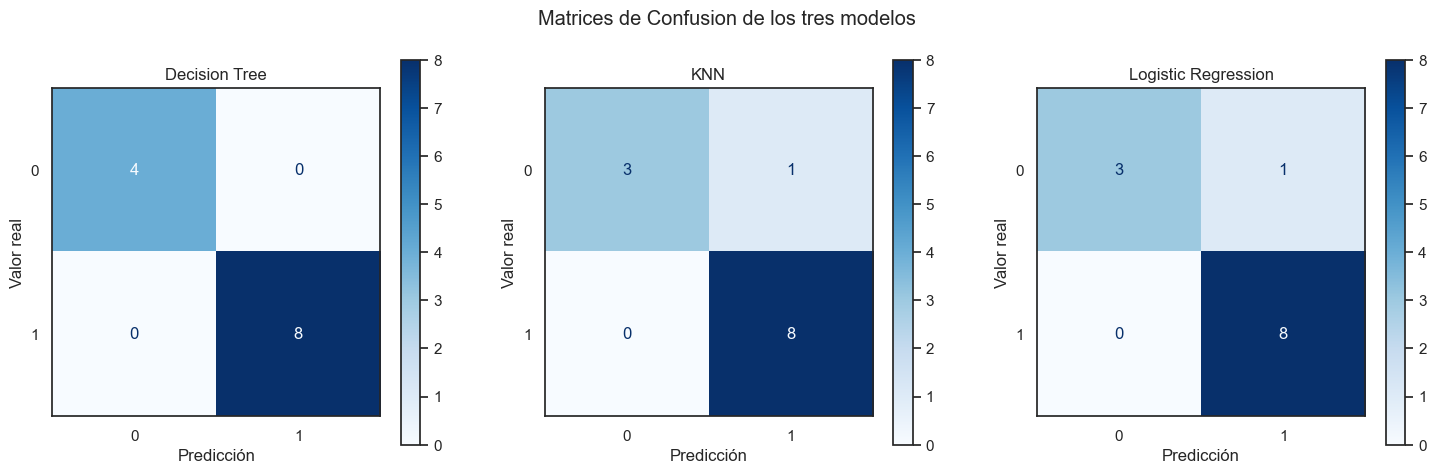

In [17]:
modelos = ["Decision Tree", "KNN", "Logistic Regression"]
predicciones = [y_pred_dt, y_pred_knn, y_pred_lr]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nombre, pred in zip(axes, modelos, predicciones):
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")

fig.suptitle("Matrices de Confusion de los tres modelos")
plt.show()

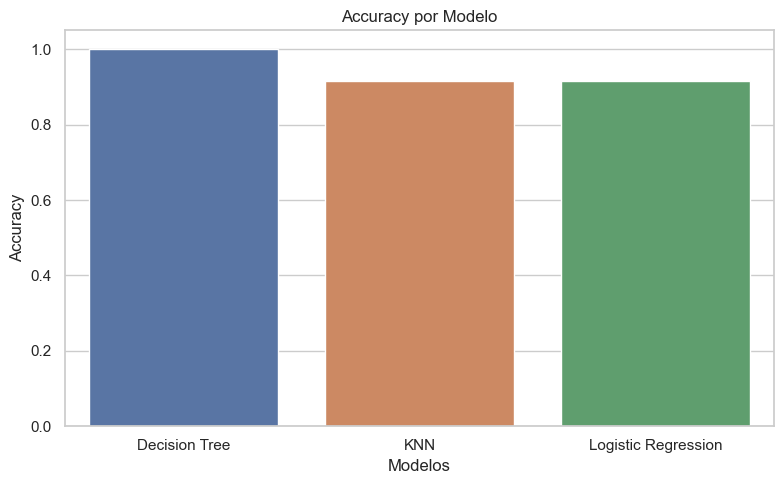

In [18]:
sns.set_theme(style="whitegrid", palette="deep")
plt.figure(figsize=(8, 5))
sns.barplot(
    data=resultados,
    x="Modelo",
    y="Accuracy",
    hue="Modelo"
)
plt.xlabel("Modelos")
plt.ylabel("Accuracy")
plt.title("Accuracy por Modelo")
plt.tight_layout()
plt.show()